# Linear Regression Training Pipeline

This notebook implements an end-to-end Linear Regression training pipeline with:
- Data loading and exploration
- Preprocessing and scaling
- Train-test split
- Model training
- Hyperparameter tuning with Optuna
- Model evaluation and validation

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer

# Mute warnings
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


C:\Users\racho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and Explore Dataset

In [3]:
DATA_PATH = '../../data/typhoon_impact_with_extreme_weather.csv' 

INPUT_FEATURES = [
    'max_sustained_wind_kph',
    'typhoon_type',
    'max_24hr_rainfall_mm',
    'total_storm_rainfall_mm',
    'min_pressure_hpa'
]

TYPHOON_TYPE_MAPPING = {
    'TD': 0, 'TS': 1, 'STS': 2, 'TY': 3, 'STY': 4
}

try:
    df = pd.read_csv(DATA_PATH)
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('/', '_')
    TARGET_COLUMN = 'cost' 

    print(f"Data Loaded. Shape: {df.shape}")
    
    # Drop rows where target is missing
    df = df.dropna(subset=[TARGET_COLUMN])

except Exception as e:
    print(f"Error: {e}")

Data Loaded. Shape: (1776, 30)


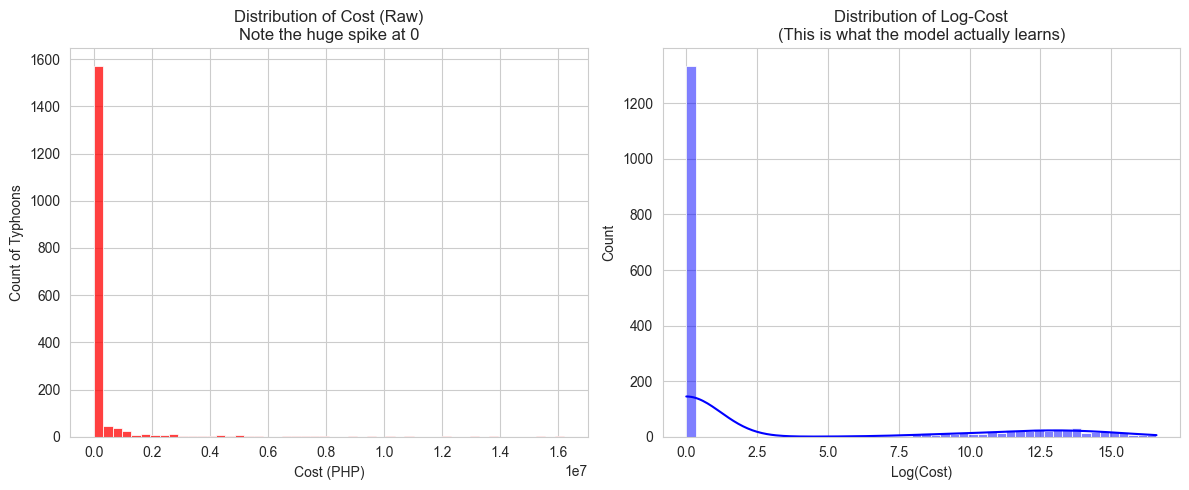

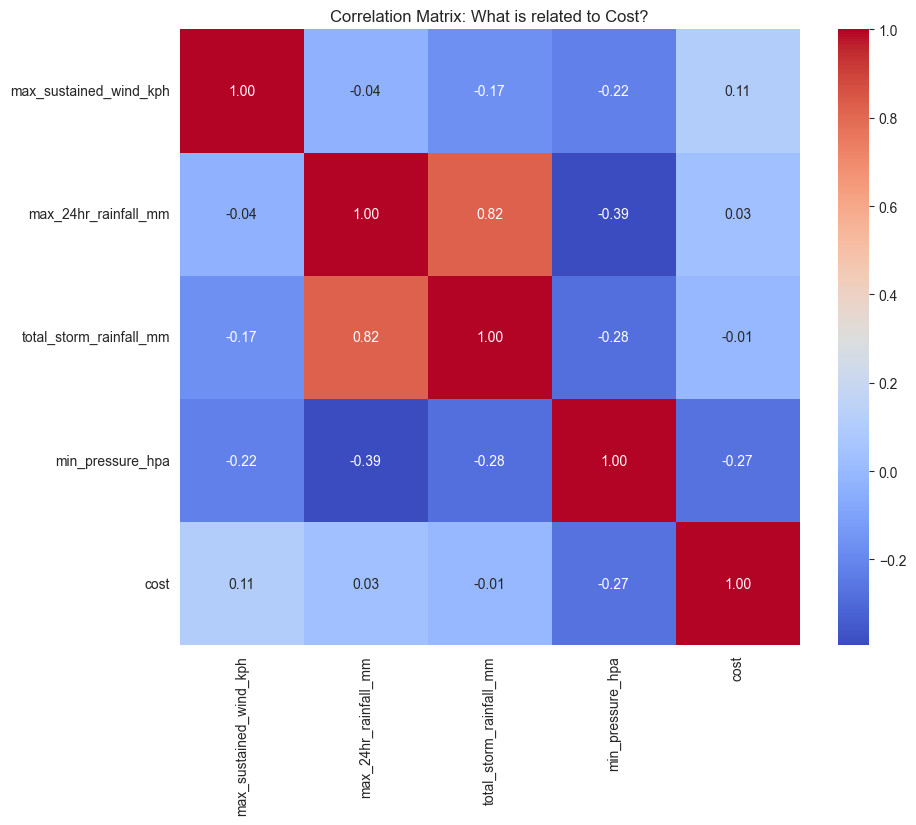

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[TARGET_COLUMN], bins=50, kde=False, color='red')
plt.title(f"Distribution of Cost (Raw)\nNote the huge spike at 0")
plt.xlabel("Cost (PHP)")
plt.ylabel("Count of Typhoons")

# B. Log-Transformed Distribution (How the model sees it)
# We add +1 to avoid log(0) error
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df[TARGET_COLUMN]), bins=50, kde=True, color='blue')
plt.title(f"Distribution of Log-Cost\n(This is what the model actually learns)")
plt.xlabel("Log(Cost)")
plt.tight_layout()
plt.show()

# C. Correlation Matrix (What drives cost?)
# We select numerical columns to see relationships
numeric_df = df[INPUT_FEATURES + [TARGET_COLUMN]].select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: What is related to Cost?")
plt.show()

## 3. Data Preprocessing

In [7]:
X = df[INPUT_FEATURES].copy()
y = df[TARGET_COLUMN].copy()

# 1. Apply Ordinal Encoding
X['typhoon_type'] = X['typhoon_type'].astype(str).str.upper().map(TYPHOON_TYPE_MAPPING)
if X['typhoon_type'].isnull().any():
    X['typhoon_type'] = X['typhoon_type'].fillna(X['typhoon_type'].median())

# 2. Add Physics Features
X['wind_power'] = X['max_sustained_wind_kph'] ** 3 
X['pressure_drop'] = 1013 - X['min_pressure_hpa']

# 3. Handle Missing Values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# 4. Polynomial Features (Interaction terms)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_array = poly.fit_transform(X_imputed)
feature_names = poly.get_feature_names_out(X_imputed.columns)
X_poly = pd.DataFrame(X_poly_array, columns=feature_names, index=X.index)

print(f"Preprocessing Complete.")
print(f"Features Expanded from {X.shape[1]} to {X_poly.shape[1]}")

Preprocessing Complete.
Features Expanded from 7 to 35


## 4. Train-Test Split

In [9]:
# Use the expanded X_poly dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

print(f"Data Split Complete.")

Data Split Complete.


## 5. Feature Scaling

In [10]:
scaler = RobustScaler()

X_train_sc_array = scaler.fit_transform(X_train)
X_test_sc_array = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_sc_array, columns=X_train.columns, index=X_train.index 
)
X_test_scaled = pd.DataFrame(
    X_test_sc_array, columns=X_test.columns, index=X_test.index
)
print("Data Scaled.")

Data Scaled.


## 6. Basic Linear Regression Model Training

In [12]:
print("Training Stage 1 (Logistic Regression)...")
y_train_class = (y_train > 0).astype(int)

baseline_clf = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
baseline_clf.fit(X_train_scaled, y_train_class)
print("Classifier Trained.")

Training Stage 1 (Logistic Regression)...
Classifier Trained.


## 7. Hyperparameter Tuning with Optuna

In [13]:
mask_nonzero = y_train > 0
X_train_nonzero = X_train_scaled[mask_nonzero]
y_train_nonzero = y_train[mask_nonzero]
y_train_log = np.log1p(y_train_nonzero) # Train on LOG

def objective(trial):
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    model = Ridge(alpha=alpha, random_state=42)
    scores = cross_val_score(model, X_train_nonzero, y_train_log, cv=3, scoring='neg_mean_squared_error')
    return scores.mean()

print("Starting Optuna Tuning...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
best_params = study.best_params
print(f"Best Alpha: {best_params['alpha']}")

[I 2025-12-11 13:52:10,833] A new study created in memory with name: no-name-0fe108f1-f662-4cbd-a0e7-d78ebaaff316
[I 2025-12-11 13:52:10,846] Trial 0 finished with value: -3.870296679352867 and parameters: {'alpha': 73.15265238769602}. Best is trial 0 with value: -3.870296679352867.
[I 2025-12-11 13:52:10,858] Trial 1 finished with value: -3.7559925815330253 and parameters: {'alpha': 20.76068460330924}. Best is trial 1 with value: -3.7559925815330253.
[I 2025-12-11 13:52:10,866] Trial 2 finished with value: -3.9533056784602594 and parameters: {'alpha': 0.029069762383076195}. Best is trial 1 with value: -3.7559925815330253.
[I 2025-12-11 13:52:10,876] Trial 3 finished with value: -3.8857191849841324 and parameters: {'alpha': 0.12644229915567778}. Best is trial 1 with value: -3.7559925815330253.
[I 2025-12-11 13:52:10,886] Trial 4 finished with value: -3.9679941317018472 and parameters: {'alpha': 0.020396868998407685}. Best is trial 1 with value: -3.7559925815330253.
[I 2025-12-11 13:52:

Starting Optuna Tuning...


[I 2025-12-11 13:52:11,046] Trial 19 finished with value: -3.735398527765063 and parameters: {'alpha': 14.429320821824831}. Best is trial 18 with value: -3.7124497601066317.
[I 2025-12-11 13:52:11,057] Trial 20 finished with value: -3.84697972541119 and parameters: {'alpha': 0.22335668323655383}. Best is trial 18 with value: -3.7124497601066317.
[I 2025-12-11 13:52:11,069] Trial 21 finished with value: -3.7119637333884423 and parameters: {'alpha': 5.527823499595972}. Best is trial 21 with value: -3.7119637333884423.
[I 2025-12-11 13:52:11,080] Trial 22 finished with value: -3.71369513353156 and parameters: {'alpha': 6.992905450019261}. Best is trial 21 with value: -3.7119637333884423.
[I 2025-12-11 13:52:11,090] Trial 23 finished with value: -3.797607844979337 and parameters: {'alpha': 35.65207870431396}. Best is trial 21 with value: -3.7119637333884423.
[I 2025-12-11 13:52:11,101] Trial 24 finished with value: -3.7176582480870173 and parameters: {'alpha': 8.740619257028671}. Best is t

Best Alpha: 5.527823499595972


In [14]:
print("Best Hyperparameters (Alpha):")
print(study.best_params)
best_params = study.best_params

Best Hyperparameters (Alpha):
{'alpha': 5.527823499595972}


## 8. Model Evaluation and Validation

In [16]:
final_reg = Ridge(**best_params, random_state=42)
final_reg.fit(X_train_nonzero, y_train_log)

# B. Find Best Threshold
probs_train = baseline_clf.predict_proba(X_train_scaled)[:, 1]
y_train_binary = (y_train > 0).astype(int)

best_threshold = 0.5
best_acc = 0
for t in np.arange(0.1, 0.9, 0.05):
    acc = accuracy_score(y_train_binary, (probs_train >= t).astype(int))
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"Optimized Threshold: {best_threshold:.2f}")

Optimized Threshold: 0.70


## 10. Model Output and Summary

In [17]:
# A. Predict
probs_test = baseline_clf.predict_proba(X_test_scaled)[:, 1]
pred_is_damage = (probs_test >= best_threshold).astype(int)

pred_log = final_reg.predict(X_test_scaled)
pred_amount = np.expm1(pred_log) # Log -> Real
pred_amount = np.maximum(pred_amount, 0) # Clamp negatives

final_predictions = pred_is_damage * pred_amount

# B. Metrics
acc = accuracy_score((y_test > 0).astype(int), pred_is_damage)
mae = mean_absolute_error(y_test, final_predictions)
r2 = r2_score(y_test, final_predictions)

print(f"📊 Final Evaluation:")
print(f"   ✅ Damage Detection Accuracy: {acc:.2%}")
print(f"   MAE: {mae:,.2f}")
print(f"   R2 Score: {r2:.4f}")

📊 Final Evaluation:
   ✅ Damage Detection Accuracy: 77.25%
   MAE: 242,689.96
   R2 Score: 0.2621


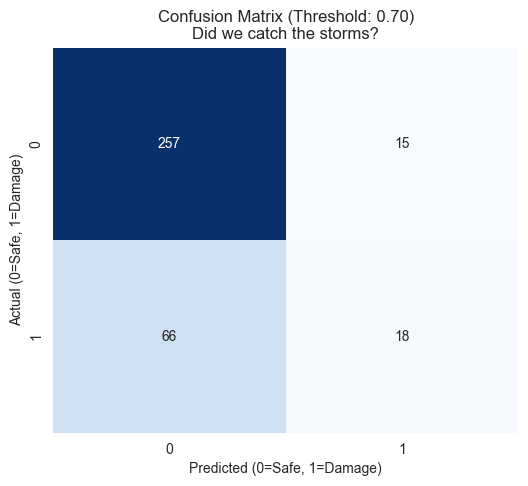

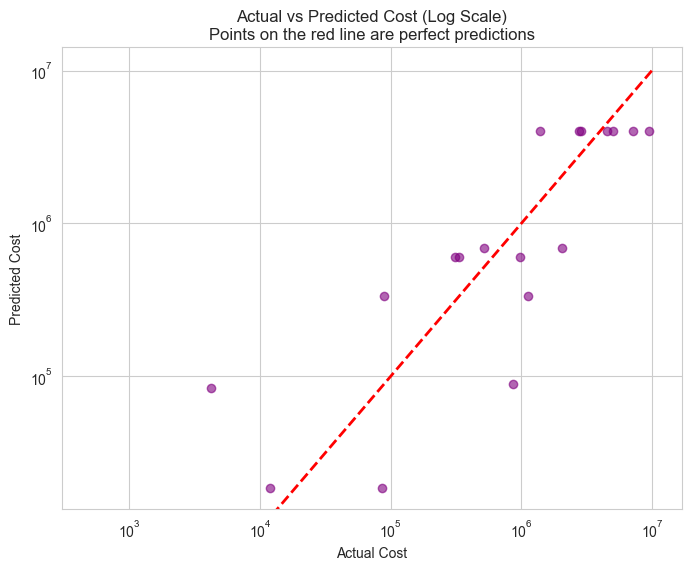

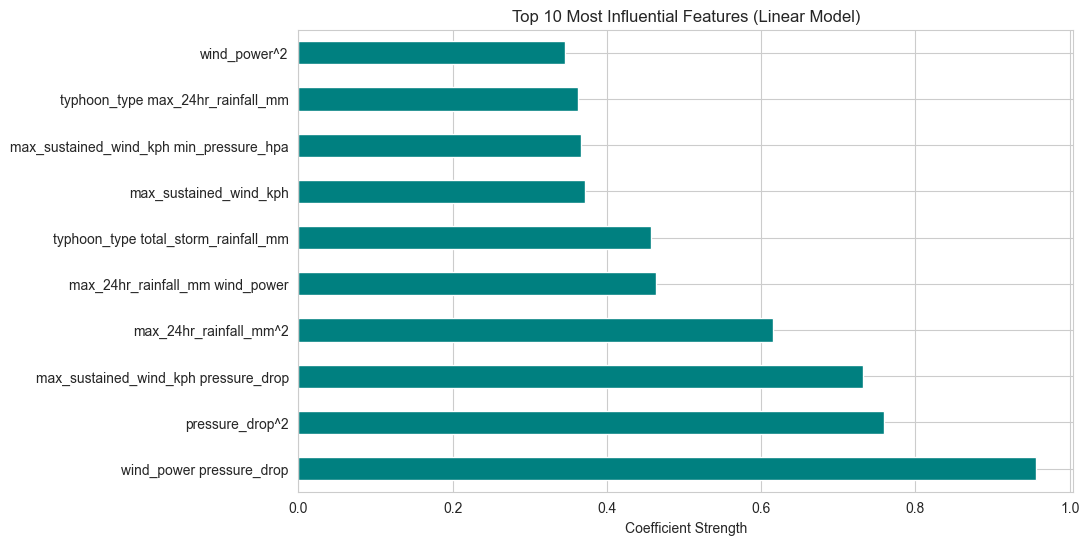

In [20]:
# 1. Confusion Matrix (How good is the Guard?)
cm = confusion_matrix((y_test > 0).astype(int), pred_is_damage)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Confusion Matrix (Threshold: {best_threshold:.2f})\nDid we catch the storms?")
plt.xlabel("Predicted (0=Safe, 1=Damage)")
plt.ylabel("Actual (0=Safe, 1=Damage)")
plt.show()

# 2. Actual vs Predicted Scatter Plot (How good is the Regressor?)
# We plot on Log Scale to see the spread better
plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_predictions, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.title("Actual vs Predicted Cost (Log Scale)\nPoints on the red line are perfect predictions")
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.show()

# 3. Feature Importance (Top 10 Linear Drivers)
# Shows which features increase the cost the most
coefs = pd.Series(final_reg.coef_, index=X_train.columns)
top_features = coefs.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='teal')
plt.title("Top 10 Most Influential Features (Linear Model)")
plt.xlabel("Coefficient Strength")
plt.show()

In [22]:
# ==========================================
# 12. SAVE ARTIFACTS
# ==========================================
results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': final_predictions})
results_df['Error'] = results_df['Actual'] - results_df['Predicted']
results_df.to_csv('predictions_final_lr.csv', index=False)

# joblib.dump(scaler, 'scaler_linear.joblib')
# joblib.dump(baseline_clf, 'classifier_logistic.joblib')
# joblib.dump(final_reg, 'regressor_ridge.joblib')

print("✅ All Results and Models Saved.")

✅ All Results and Models Saved.
